In [248]:
#Library importations
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [249]:
#Directory of the dataset
directory = "C:/Users/j-a-b/Documents/OpenClassrooms/Projet 5 MH/Data/"
#Pattern to match the CSV files
pattern = os.path.join(directory, "*.csv")
#List to hold the dataframes
file_list = glob.glob(pattern)
#Read each CSV file and append it into a unified dataframe
pmvl = pd.concat((pd.read_csv(file, sep=",") for file in file_list), ignore_index=True)

In [250]:
print(f"Found {len(file_list)} CSV files in the directory: {directory}")
print("-" * 60)
print("Shape of the combined dataframe:", pmvl.shape)
print("-" * 60)
print("Missing values in each column:")
print(pmvl.isnull().sum())

Found 50 CSV files in the directory: C:/Users/j-a-b/Documents/OpenClassrooms/Projet 5 MH/Data/
------------------------------------------------------------
Shape of the combined dataframe: (16161, 44)
------------------------------------------------------------
Missing values in each column:
PMVL[Source Name]                                      0
PMVL[Holding date]                                     0
PMVL[GROUPE]                                           0
PMVL[ENTITE]                                           0
PMVL[Selected Fund code]                               0
PMVL[ISIN]                                             0
PMVL[Orig. name]                                       0
PMVL[Quote]                                            0
PMVL[Quote Date]                                       0
PMVL[Quote Mode]                                       0
PMVL[Quantity]                                         0
PMVL[Inst. Nominal]                                    0
PMVL[Purch. Val. (clean

Cleaning data

In [252]:
columns_to_clean = ["PMVL[PRMP VNC]"]

#Deleting spaces in the column
for column in columns_to_clean:
    pmvl[column] = (pmvl[column].astype(str).str.replace(" ", "", regex=False).replace("nan", np.nan).astype(float))



Creating target

In [253]:
#Reordering columns to have a better readability by keys
keys = [
    "PMVL[ENTITE]", 
    "PMVL[Selected Fund code]", 
    "PMVL[Ref Unik Asset]",
    "PMVL[ISIN]",
    "PMVL[PRMP PMVL]",
    "PMVL[PMVL Estimé]",
    "PMVL[Holding date]"
    ]
other_columns = [col for col in pmvl.columns if col not in keys]
pmvl = pmvl[keys + other_columns]

In [254]:
#Create a new column target
#Have We asserted the PMVL[PMVL Estimé] on the next day?
#yes=True, no=False
#We take the today's PMVL[PMVL Estimé] we compare it with the PMVL[PRMP PMVL] of tomorrow
#threshold +- 5%
#Keys to group by:
keys = [
    "PMVL[ENTITE]", 
    "PMVL[Selected Fund code]", 
    "PMVL[Ref Unik Asset]",
    "PMVL[ISIN]"
]

# 1. Sort so that inside each key-combination, dates are in order
pmvl_sorted = pmvl.sort_values(
    by=keys + ["PMVL[Holding date]"]
)

# 2. Compute "tomorrow's PRMP PMVL" per (ENTITE, Fund, Asset, ISIN)
pmvl_sorted["PRMP_PMVL_tomorrow"] = (
    pmvl_sorted
    .groupby(keys)["PMVL[PRMP PMVL]"]
    .shift(-1)
)

# 3. Compare today's estimate with tomorrow's realized PRMP PMVL (±5%)
pmvl_sorted["Target"] = (
    (pmvl_sorted["PRMP_PMVL_tomorrow"] >= pmvl_sorted["PMVL[PMVL Estimé]"] * 0.95) &
    (pmvl_sorted["PRMP_PMVL_tomorrow"] <= pmvl_sorted["PMVL[PMVL Estimé]"] * 1.05)
).astype(int)

# 4. Drop duplicates per key + day (if needed)
pmvl_sorted = pmvl_sorted.drop_duplicates(
    subset=keys + ["PMVL[Holding date]"]
)

# 5. Reorder columns
pmvl_sorted = pmvl_sorted[
    keys 
    + ["PMVL[Holding date]", "PMVL[PRMP PMVL]", "PMVL[PMVL Estimé]"] + ["PRMP_PMVL_tomorrow", "Target"]
    + [c for c in pmvl_sorted.columns if c not in keys + ["PMVL[Holding date]", "Target", "PMVL[PRMP PMVL]", "PMVL[PMVL Estimé]", "PRMP_PMVL_tomorrow"]]
]

In [255]:
#drop line where PRMP_PMVL_tomorrow is null, because next day that position doesn't exist anymore (was closed)
pmvl_sorted = pmvl_sorted[~pmvl_sorted["PRMP_PMVL_tomorrow"].isnull()]

In [256]:
#csv exportation
pmvl_sorted.to_csv("C:/Users/j-a-b/Documents/OpenClassrooms/Projet 5 MH/Notebook/pmvl_sorted.csv", index=False)

Dataset defrief

In [257]:
#Assign a ticker "pas de ticker" to all the lines, because we don't have this information in the dataset, but it's required for the model, we will use the "PMVL[Selected Fund code]" as a proxy for the ticker, because it's the only column that can be used as a unique identifier for each line, and it contains a lot of missing values, but we will fill them with "pas de ticker" to avoid losing too much data.
pmvl_sorted["PMVL[Parametres_Indices.TICKER]"] = pmvl_sorted["PMVL[Parametres_Indices.TICKER]"].fillna("pas de ticker")
#Filling missing values in "PMVL[Ref Unik Codes]" with "pas de code", because it's the only column that can be used as a unique identifier for each line, and it contains a lot of missing values, but we will fill them with "pas de code" to avoid losing too much data.
pmvl_sorted["PMVL[Ref Unik Codes]"] = pmvl_sorted["PMVL[Ref Unik Codes]"].fillna("pas de code")

(11390, 17)
<class 'pandas.core.frame.DataFrame'>
Index: 11390 entries, 678 to 15234
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   PMVL[Holding date]               11390 non-null  object 
 1   PMVL[ENTITE]                     11390 non-null  object 
 2   PMVL[Selected Fund code]         11390 non-null  object 
 3   PMVL[Ref Unik Asset]             11390 non-null  object 
 4   PMVL[ISIN]                       11390 non-null  object 
 5   PMVL[Parametres_Indices.TICKER]  11390 non-null  object 
 6   PMVL[CIC]                        11390 non-null  object 
 7   PMVL[3A]                         11390 non-null  object 
 8   PMVL[Ptf name]                   11390 non-null  object 
 9   PMVL[PRMP PMVL]                  11390 non-null  float64
 10  PMVL[PMVL Estimé]                11390 non-null  float64
 11  PMVL[PFMIndice.Perf J / J-1]     11390 non-null  float64
 12  PMVL[PRMP

Target
1    8481
0    2909
Name: count, dtype: int64

Target
1    74.460053
0    25.539947
Name: proportion, dtype: float64

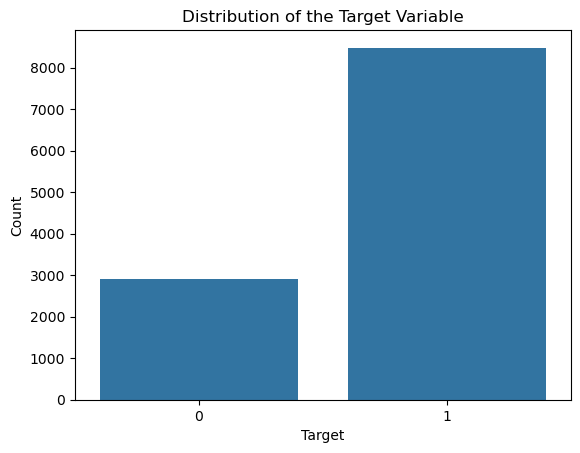

In [ ]:
#Categorical features
categorical_features = [
    "PMVL[ENTITE]", 
    "PMVL[Selected Fund code]", 
    "PMVL[Ref Unik Asset]",
    "PMVL[Parametres_Indices.TICKER]",
    "PMVL[CIC]",
    "PMVL[3A]",
    "PMVL[Ptf name]"
]

#Numerical features
numerical_features = [
    "PMVL[PRMP PMVL]", 
    "PMVL[PMVL Estimé]", 
    "PMVL[PFMIndice.Perf J / J-1]",
    "PMVL[PRMP VNC]",
    "PMVL[Quantity]",
    "PMVL[Quote]",
    "PMVL[PRMP MtM]"
]

#Target variable
target_variable = "Target"

df = pmvl_sorted[["PMVL[Holding date]"] + categorical_features + numerical_features + [target_variable]]
print(df.shape)
print(df.info())

#Show the distribution of the target variable
display(df.value_counts("Target"))
#As a percentage
display(df.value_counts("Target", normalize=True) * 100)
#Show as a chart the distribution of the target variable
sns.countplot(x="Target", data=df)
plt.title("Distribution of the Target Variable")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

Pipeline

In [ ]:
import numpy as np
import pandas as pd

def add_features(X, numerical_features):
    X = X.copy()

    # Ensure holding date is datetime once
    X["PMVL[Holding date]"] = pd.to_datetime(X["PMVL[Holding date]"])

    # Clean numeric columns: remove spaces, convert, fill NaN with median
    for col in numerical_features:
        X[col] = (
            X[col]
            .astype(str)
            .str.replace(" ", "", regex=False)
            .replace("nan", np.nan)
            .astype(float)
        )
        X[col] = X[col].fillna(X[col].median())

    # Avoid division by zero
    eps = 1e-9
    denom_est = X["PRMP_PMVL_tomorrow"].replace(0, eps)
    denom_real = X["PMVL[PRMP PMVL]"].replace(0, eps)

    # Ratios
    X["Ratio_Estimate"] = X["PMVL[PMVL Estimé]"] / denom_est
    X["Ratio_Realized"] = X["PRMP_PMVL_tomorrow"] / denom_real

    # Percentage error (in %)
    X["Percentage_Error"] = (X["PRMP_PMVL_tomorrow"] - X["PMVL[PMVL Estimé]"]) / denom_est * 100

    # Calendar features
    X["Holding_Month"] = X["PMVL[Holding date]"].dt.month
    X["Holding_Day"] = X["PMVL[Holding date]"].dt.day

    return X

In [260]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
#models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Encoding variables

In [261]:
#Numerical encoding
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
]) 

#Categorical encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])  
#Combining both transformations
Preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [262]:
df

,PMVL[Holding date],PMVL[ENTITE],PMVL[Selected Fund code],PMVL[Ref Unik Asset],PMVL[ISIN],PMVL[Parametres_Indices.TICKER],PMVL[CIC],PMVL[3A],PMVL[Ptf name],PMVL[PRMP PMVL],PMVL[PMVL Estimé],PMVL[PFMIndice.Perf J / J-1],PMVL[PRMP VNC],PMVL[Quantity],PMVL[Quote],PMVL[PRMP MtM],Target
678,2025-12-30T00:00:00,AUXIA,AUX2A,FC_Div,FR0011662014,pas de ticker,XL44,Hors mandat AUXIA AG,AUXIA HM ACT NC,2991749.85,2991749.85,0.0,2306420.67,228.0,23237.59,5298170.52,1
58,2025-12-31T00:00:00,AUXIA,AUX2A,FC_Div,FR0011662014,pas de ticker,XL44,Hors mandat AUXIA AG,AUXIA HM ACT NC,2991749.85,2991749.85,0.0,2306420.67,228.0,23237.59,5298170.52,1
1293,2026-01-01T00:00:00,AUXIA,AUX2A,FC_Div,FR0011662014,pas de ticker,XL44,Hors mandat AUXIA AG,AUXIA HM ACT NC,2991749.85,2991749.85,0.0,2306420.67,228.0,23237.59,5298170.52,1
2551,2026-01-02T00:00:00,AUXIA,AUX2A,FC_Div,FR0011662014,pas de ticker,XL44,Hors mandat AUXIA AG,AUXIA HM ACT NC,2991749.85,2991749.85,0.0,2306420.67,228.0,23237.59,5298170.52,1
3738,2026-01-05T00:00:00,AUXIA,AUX2A,FC_Div,FR0011662014,pas de ticker,XL44,Hors mandat AUXIA AG,AUXIA HM ACT NC,2991749.85,2991749.85,0.0,2306420.67,228.0,23237.59,5298170.52,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14313,2026-03-12T00:00:00,QUATREM,QUA2B,FC_Mon,FR0000009987,Monetaire,FR43,Hors mandat QUATREM AG,QUATREM HM ACT NC,100182.62,100182.62,0.0,30752249.62,148.0,208462.38,30852432.24,1
14545,2026-03-13T00:00:00,QUATREM,QUA2B,FC_Mon,FR0000009987,Monetaire,FR43,Hors mandat QUATREM AG,QUATREM HM ACT NC,101995.62,101995.62,0.0,30752249.62,148.0,208474.63,30854245.24,0
14777,2026-03-16T00:00:00,QUATREM,QUA2B,FC_Mon,FR0000009987,Monetaire,FR43,Hors mandat QUATREM AG,QUATREM HM ACT NC,107271.82,107271.82,0.0,30752249.62,148.0,208510.28,30859521.44,1
15009,2026-03-17T00:00:00,QUATREM,QUA2B,FC_Mon,FR0000009987,Monetaire,FR43,Hors mandat QUATREM AG,QUATREM HM ACT NC,108834.70,108834.70,0.0,30752249.62,148.0,208520.84,30861084.32,0


In [263]:
#Random Forest Classifier 
clf = RandomForestClassifier(random_state=42, n_estimators=658, max_depth=5, max_features=0.3, min_samples_split=12, min_samples_leaf=7,
                             n_jobs=-1
                             ,class_weight="balanced"
                             )

#Model pipeline
model_pipeline = Pipeline(steps=[
    ("feature_engineering", FunctionTransformer(add_features, validate=False)),
    ("preprocessor", Preprocessor),
    ("clf", clf)
])

#temporal train-test split
#We will use the first 80% of the data for training and the last 20% for testing, to respect the temporal order of the data and avoid data leakage.
train_size = int(0.8 * len(df))
X_train = df.iloc[:train_size].drop(columns=[target_variable])
y_train = df.iloc[:train_size][target_variable]
X_test = df.iloc[train_size:].drop(columns=[target_variable])
y_test = df.iloc[train_size:][target_variable]